### Import Libraries

In [1]:
import pandas as pd
import numpy as np

import tensorflow
from tensorflow.keras import Sequential
from tensorflow.keras.metrics import Accuracy

from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator 
from tensorflow.keras.layers import Conv2D,Dense,AveragePooling2D,MaxPooling2D,Flatten,Dropout

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

### Data Gathering and Preprocessing

In [6]:
image_size = (224,224)

data_generator = ImageDataGenerator(rescale= 1/255, 
                                    validation_split= 0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True,
                                   width_shift_range=0.1,
                                   height_shift_range=0.1,
                                   shear_range=0.1)

train_generator = data_generator.flow_from_directory( r"D:\Velocity\Practice\Deep_Learning\Dataset\Plant_Detection",
                                    target_size=image_size, 
                                    batch_size=32,
                                    class_mode='categorical',
                                    subset='training')

val_generator = data_generator.flow_from_directory( r"D:\Velocity\Practice\Deep_Learning\Dataset\Plant_Detection",
                                    target_size=image_size, 
                                    batch_size=32,
                                    class_mode='categorical',
                                    subset='validation')


Found 640 images belonging to 4 classes.
Found 160 images belonging to 4 classes.


### Model Building

In [7]:
model = Sequential()

# --- CNN Layer-1 ----
model.add(Conv2D( filters=32, kernel_size= (3,3), strides= (1,1), activation = 'relu', input_shape = (224,224,3)))
model.add(MaxPooling2D(pool_size=(2,2)))
# ---- CNN Layer -2 ---
model.add(Conv2D(filters = 64, kernel_size = (3,3), strides = (1,1), activation = 'relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
# ---- CNN Layer -3 ---
model.add(Conv2D(filters = 64, kernel_size = (3,3), strides = (1,1), activation = 'relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

#--------MLP Layer----------
model.add(Dense(units = 64, activation = 'relu'))
model.add(Dropout(0.3))
# Output layer
model.add(Dense(units= train_generator.num_classes, activation = 'softmax')) 

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 52, 52, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 26, 26, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 43264)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │       2,768,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 4)                   │             260 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,825,540 (10.78 MB)

 Trainable params: 2,825,540 (10.78 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(optimizer= 'adam', loss = 'categorical_crossentropy', metrics= ['accuracy'])
histroy = model.fit(train_generator,validation_data= val_generator, epochs = 20, verbose= 1, batch_size=32)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 57s 3s/step - accuracy: 0.3328 - loss: 1.4118 - val_accuracy: 0.4437 - val_loss: 1.1478
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.5953 - loss: 0.9548 - val_accuracy: 0.8000 - val_loss: 0.6433
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.7547 - loss: 0.6226 - val_accuracy: 0.8062 - val_loss: 0.5702
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.8094 - loss: 0.5308 - val_accuracy: 0.8188 - val_loss: 0.4682
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.8109 - loss: 0.5202 - val_accuracy: 0.8188 - val_loss: 0.4438
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.8406 - loss: 0.4200 - val_accuracy: 0.8750 - val_loss: 0.3040
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.8516 - loss: 0.3997 - val_accuracy: 0.8938 - val_loss: 0.3053
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.8266 - loss: 0.4304 - val_accuracy: 0.9062 - val_loss:

In [10]:
histroy.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

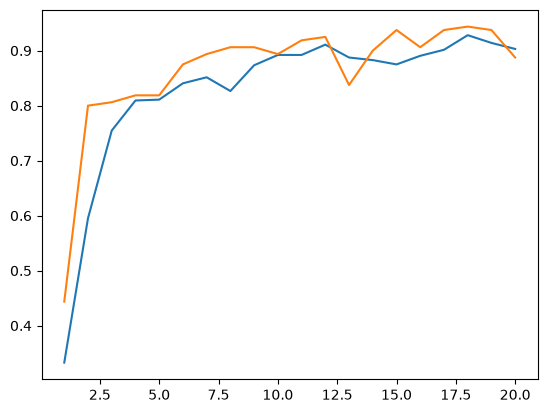

In [11]:
epoch_range = range(1,21)
plt.plot(epoch_range,histroy.history['accuracy'])
plt.plot(epoch_range,histroy.history['val_accuracy'])

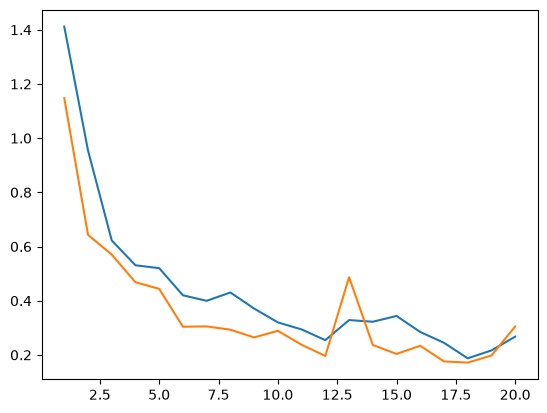

In [13]:
plt.plot(epoch_range,histroy.history['loss'])
plt.plot(epoch_range,histroy.history['val_loss'])

#### Results
-> Not training model further then 20  epochs cause the models best results are coming between epoch 19-20 after that model not 
   procurring good results

### Model Testing

In [17]:
print("Keras Class Mapping:", train_generator.class_indices)

Keras Class Mapping: {'Apple__Black_rot': 0, 'Apple___Apple_scab': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3}


In [27]:
img_path = r"D:\Velocity\Datasets\Image_Dataset\PlantVillage\train\Apple___Black_rot\f3ff804e-bca4-4a23-9af9-1f5b8c5c9980___JR_FrgE.S 3053.JPG"
img = image.load_img(img_path, target_size=(224, 224))

# 2. Process image for prediction
img_array = image.img_to_array(img)
img_array = img_array / 255.0  # This matches the rescale=1/255 used in ImageDataGenerator
test_array = img_array.reshape(1, 224, 224, 3)  # Reshaping to (batch_size, height, width, channels)

# 3. Predict across all classes
predictions = model.predict(test_array)
predicted_class_index = np.argmax(predictions)

# 4. Map index to class name
# Note: flow_from_directory automatically sorts classes alphabetically based on folder names.
class_names = ['Black rot Plant', 'Scab Plant', 'Cedar Rust Plant', 'Healthy Plant']
predicted_class_name = class_names[predicted_class_index]

# 5. Output results
print(f"Probabilities for all 4 classes: {predictions}")
print(f"Predicted Image Class Index is: {predicted_class_index}")
print(f"Predicted Image Class is: {predicted_class_name}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
Probabilities for all 4 classes: [[9.9999666e-01 4.6161972e-09 1.0618802e-13 3.2863943e-06]]
Predicted Image Class Index is: 0
Predicted Image Class is: Black rot Plant


In [26]:
img_path = r"D:\Velocity\Datasets\Image_Dataset\PlantVillage\train\Apple___Apple_scab\fcd4d0fd-30c9-4b05-b0ea-ca74fd3cad72___FREC_Scab 3510.JPG"
img = image.load_img(img_path, target_size=(224, 224))

# 2. Process image for prediction
img_array = image.img_to_array(img)
img_array = img_array / 255.0  # This matches the rescale=1/255 used in ImageDataGenerator
test_array = img_array.reshape(1, 224, 224, 3)  # Reshaping to (batch_size, height, width, channels)

# 3. Predict across all classes
predictions = model.predict(test_array)
predicted_class_index = np.argmax(predictions)

# 4. Map index to class name
# Note: flow_from_directory automatically sorts classes alphabetically based on folder names.
class_names = ['Black rot Plant', 'Scab Plant', 'Cedar Rust Plant', 'Healthy Plant']
predicted_class_name = class_names[predicted_class_index]

# 5. Output results
print(f"Probabilities for all 4 classes: {predictions}")
print(f"Predicted Image Class Index is: {predicted_class_index}")
print(f"Predicted Image Class is: {predicted_class_name}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Probabilities for all 4 classes: [[2.0899216e-09 9.9998868e-01 6.0971647e-14 1.1312163e-05]]
Predicted Image Class Index is: 1
Predicted Image Class is: Scab Plant


### Save Model

In [29]:
import json
# ---- Save model---
model.save("Apple_Plant_clf_model.keras")
# ---Save class names---
with open("Apple_plnt_class.json","w") as f:
    json.dump(class_names,f)
